# HW1: Point and Interval Estimates
**Advanced Topics in Applied Statistics, Spring 2026**  
**Deadline:** February 19, 2026, 12:00


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2, poisson, expon, gamma
from scipy.optimize import brentq

rng = np.random.default_rng(42)
FIGURES_DIR = 'figures/'

## Problem 1 (3 points)

Data: `[1, 1, 0, 0, 2, 4, 1, 2, 0, 3]` — monthly accident counts, Poisson model.  
Target: $\theta = P(\text{no accident}) = e^{-\lambda}$.

### 1a. $\hat{\theta}_{MLE}$

In [2]:
# Data
data = np.array([1, 1, 0, 0, 2, 4, 1, 2, 0, 3])
n = len(data)

# MLE of lambda for Poisson: lambda_hat = x_bar  (
lambda_hat = data.mean()

# theta = P(no accident) = e^{-lambda}  =>  theta_hat = e^{-lambda_hat}
theta_hat = np.exp(-lambda_hat)

print(f'n            = {n}')
print(f'lambda_hat   = {lambda_hat:.4f}')
print(f'theta_hat    = exp(-{lambda_hat}) = {theta_hat:.6f}')

n            = 10
lambda_hat   = 1.4000
theta_hat    = exp(-1.4) = 0.246597


### 1b. Bias of $\hat{\theta}_{MLE}$

**Analytical bias.** For Poisson iid $X_1,\dots,X_n$ with parameter $\lambda$, the MLE is $\hat\lambda = \bar X$ and $\hat\theta = e^{-\hat\lambda}$.

$$\mathbb{E}[\hat\theta] = \mathbb{E}[e^{-\bar X}] = \prod_{i=1}^{n} \mathbb{E}[e^{-X_i/n}]$$

The MGF of $\text{Pois}(\lambda)$ at $t$ is $e^{\lambda(e^t - 1)}$, so $\mathbb{E}[e^{-X_i/n}] = e^{\lambda(e^{-1/n}-1)}$.

$$\mathbb{E}[\hat\theta] = e^{n\lambda(e^{-1/n}-1)}, \qquad \text{Bias} = e^{n\lambda(e^{-1/n}-1)} - e^{-\lambda}$$

In [3]:
# Analytical bias
theta_true = np.exp(-lambda_hat)   # we treat lambda_hat as our best estimate of lambda
E_theta_hat = np.exp(n * lambda_hat * (np.exp(-1 / n) - 1))
bias_analytical = E_theta_hat - theta_true

print(f'E[theta_hat]      = {E_theta_hat:.6f}')
print(f'theta_true        = {theta_true:.6f}')
print(f'Bias (analytical) = {bias_analytical:.6f}')

# MC bias
boot = 50_000
theta_hats = np.zeros(boot)
for i in range(boot):
    X = rng.poisson(lam=lambda_hat, size=n)
    theta_hats[i] = np.exp(-X.mean())

bias_mc = theta_hats.mean() - theta_true

print(f'\nBias (MC, {boot} runs) = {bias_mc:.6f}')
print(f'Analytical vs MC diff  = {abs(bias_analytical - bias_mc):.2e}')

E[theta_hat]      = 0.263876
theta_true        = 0.246597
Bias (analytical) = 0.017279

Bias (MC, 50000 runs) = 0.017652
Analytical vs MC diff  = 3.73e-04


### 1c. Variance via delta method; compare to bias

For $g(\lambda) = e^{-\lambda}$, $g'(\lambda) = -e^{-\lambda}$:

$$\text{Var}(\hat\theta) \approx [g'(\hat\lambda)]^2 \cdot \text{Var}(\hat\lambda) = e^{-2\lambda} \cdot \frac{\lambda}{n}$$

Fisher information for $n$ iid Poisson observations: $I(\lambda) = n/\lambda$, so $\text{Var}(\hat\lambda) = \lambda/n$.

In [4]:
# Delta method variance
var_lambda_hat = lambda_hat / n                          # Var(lambda_hat) = lambda / n
var_theta_delta = np.exp(-2 * lambda_hat) * var_lambda_hat  # [g']^2 * Var(lambda_hat)

# MC variance (reuse theta_hats from 1b)
var_theta_mc = theta_hats.var()

print(f'Var(theta_hat) delta method : {var_theta_delta:.6f}')
print(f'Var(theta_hat) MC           : {var_theta_mc:.6f}')
print(f'sqrt(Var) delta             : {np.sqrt(var_theta_delta):.6f}')
print()
print(f'|Bias|       = {abs(bias_analytical):.6f}')
print(f'sqrt(Var)    = {np.sqrt(var_theta_delta):.6f}')
print(f'|Bias| / sqrt(Var) = {abs(bias_analytical) / np.sqrt(var_theta_delta):.4f}')
print()
print('to the standard deviation. The MLE is dominated by variance, not bias.')

Var(theta_hat) delta method : 0.008513
Var(theta_hat) MC           : 0.009498
sqrt(Var) delta             : 0.092268

|Bias|       = 0.017279
sqrt(Var)    = 0.092268
|Bias| / sqrt(Var) = 0.1873

to the standard deviation. The MLE is dominated by variance, not bias.


## Problem 2 (2 points)

Efron (1993) "implied" likelihood: $L(\theta) = c_{xx}(\theta) / c_x(\theta)$.  
Compare to standard likelihood for Normal ($\mu, \sigma$) and Poisson ($\lambda$).

**Efron's implied likelihood.**

The confidence density $c_x(\theta)$ is the derivative of the p-value function w.r.t. the parameter $\theta$:

$$c_x(\theta) = \frac{d}{d\theta}\, p\text{-value}(\theta)$$

Efron (1993) defines the *implied* likelihood by doubling the data (e.g. $[1,2,3] \to [1,1,2,2,3,3]$, so $n \to 2n$ with scaled sufficient statistics):

$$L_{\text{implied}}(\theta) = \frac{c_{xx}(\theta)}{c_x(\theta)}$$

We compare this to the standard likelihood for three cases:
1. $X_i \sim N(\mu, 1)$, $n=50$, vary $\mu$ (fix $\sigma=1$)
2. $X_i \sim N(0, \sigma^2)$, $n=50$, vary $\sigma$ (fix $\mu=0$)
3. $X_i \sim \text{Pois}(\lambda)$, $n=50$, vary $\lambda$

In [5]:
def derivative(f, x0, dx=1e-6):
    return (f(x0 + dx) - f(x0 - dx)) / (2 * dx)

# Generate samples
np.random.seed(42)
n_p2 = 50
mu_true, sigma_true, lam_true = 0.0, 1.0, 1.0

# Normal sample
X_norm = np.random.normal(mu_true, sigma_true, n_p2)
xbar = X_norm.mean()
sum_sq = np.sum((X_norm - mu_true)**2)  # sum (x_i - mu_known)^2 for Case 2

# Poisson sample
X_pois = np.random.poisson(lam_true, n_p2)
S_pois = X_pois.sum()

print(f"Normal sample: n={n_p2}, x_bar={xbar:.4f}, sum_sq={sum_sq:.4f}")
print(f"Poisson sample: n={n_p2}, S={S_pois}")

Normal sample: n=50, x_bar=-0.2255, sum_sq=45.2571
Poisson sample: n=50, S=37


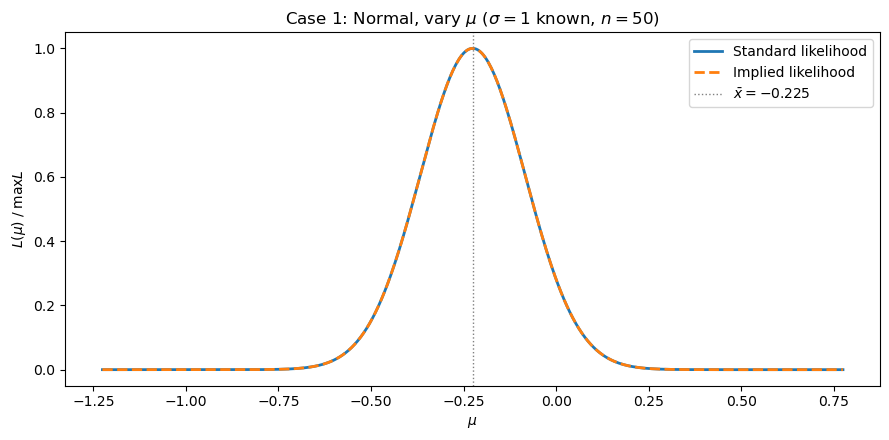

In [6]:
# p-value: P(X_bar >= xbar_obs | mu) — upper-tail
p_mu    = lambda mu: 1 - norm.cdf(xbar, loc=mu, scale=sigma_true / np.sqrt(n_p2))
p_mu_2x = lambda mu: 1 - norm.cdf(xbar, loc=mu, scale=sigma_true / np.sqrt(2 * n_p2))

mu_grid = np.linspace(xbar - 1.0, xbar + 1.0, 500)

# Confidence densities via numerical derivative (cell-13 helper)
c_x  = np.array([derivative(p_mu,    m, dx=1e-5) for m in mu_grid])
c_xx = np.array([derivative(p_mu_2x, m, dx=1e-5) for m in mu_grid])

# Implied likelihood (clip near-zero c_x for safety)
eps = 1e-30
L_implied = c_xx / np.where(np.abs(c_x) > eps, c_x, np.nan)
L_implied_norm = L_implied / np.nanmax(L_implied)

# Standard likelihood (log-scale, then exponentiate & normalize)
log_L_standard = np.array([norm.logpdf(X_norm, loc=m, scale=sigma_true).sum() for m in mu_grid])
L_standard = np.exp(log_L_standard - log_L_standard.max())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(mu_grid, L_standard, label='Standard likelihood', lw=2)
ax.plot(mu_grid, L_implied_norm, '--', label='Implied likelihood', lw=2)
ax.axvline(xbar, color='gray', ls=':', lw=1, label=rf'$\bar x = {xbar:.3f}$')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$L(\mu)\;/\;\max L$')
ax.set_title(r'Case 1: Normal, vary $\mu$ ($\sigma=1$ known, $n=50$)')
ax.legend()
plt.tight_layout()
plt.show()

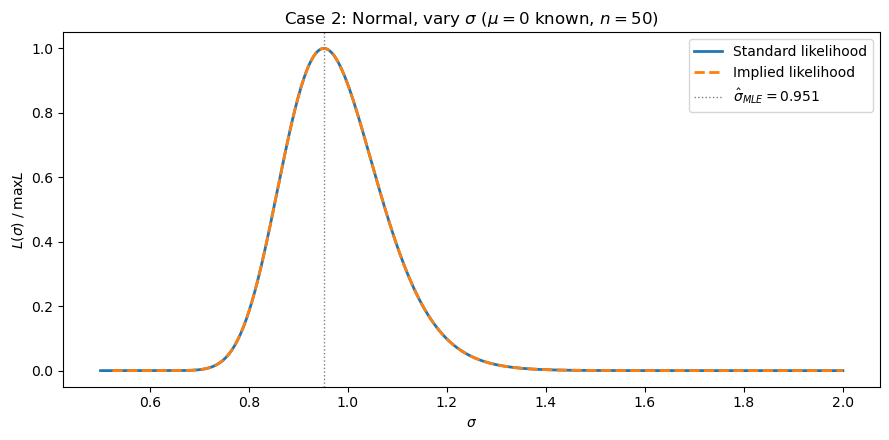

In [7]:
# sum_sq / sigma^2 ~ chi2(n)  when mu is known

# p-value: P(chi2 >= sum_sq/sig^2 | sig)
p_sig    = lambda sig: 1 - chi2.cdf(sum_sq / sig**2, df=n_p2)
# Doubled data: 2*sum_sq / sig^2 ~ chi2(2n)
p_sig_2x = lambda sig: 1 - chi2.cdf(2 * sum_sq / sig**2, df=2 * n_p2)

sigma_grid = np.linspace(0.5, 2.0, 500)

c_x_sig  = np.array([derivative(p_sig,    s, dx=1e-5) for s in sigma_grid])
c_xx_sig = np.array([derivative(p_sig_2x, s, dx=1e-5) for s in sigma_grid])

eps = 1e-30
L_implied_sig = c_xx_sig / np.where(np.abs(c_x_sig) > eps, c_x_sig, np.nan)
L_implied_sig_norm = L_implied_sig / np.nanmax(L_implied_sig)

# Standard likelihood
log_L_sig = np.array([
    norm.logpdf(X_norm, loc=mu_true, scale=s).sum() for s in sigma_grid
])
L_standard_sig = np.exp(log_L_sig - log_L_sig.max())

sigma_mle = np.sqrt(sum_sq / n_p2)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sigma_grid, L_standard_sig, label='Standard likelihood', lw=2)
ax.plot(sigma_grid, L_implied_sig_norm, '--', label='Implied likelihood', lw=2)
ax.axvline(sigma_mle, color='gray', ls=':', lw=1,
           label=rf'$\hat\sigma_{{MLE}} = {sigma_mle:.3f}$')
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$L(\sigma)\;/\;\max L$')
ax.set_title(r'Case 2: Normal, vary $\sigma$ ($\mu=0$ known, $n=50$)')
ax.legend()
plt.tight_layout()
plt.show()

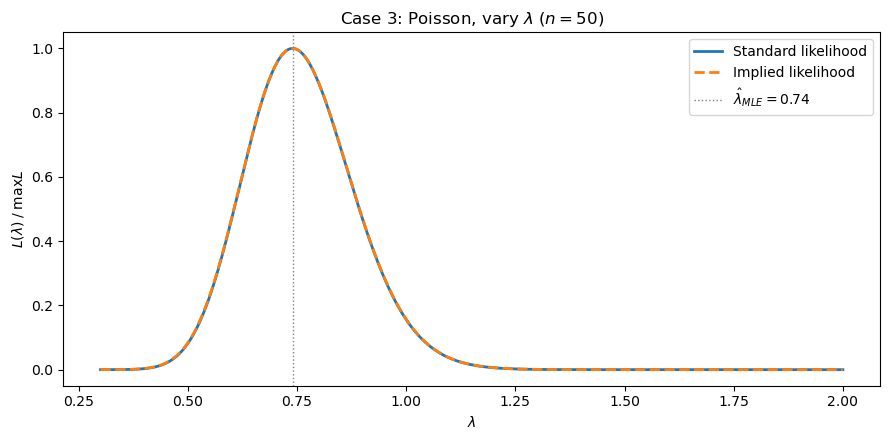

likelihood in all three cases, confirming Efron's result.


In [8]:
# S = sum(X_i) ~ Poisson(n*lambda)

# Upper-tail p-value
p_lam    = lambda lam: (1 - poisson.cdf(S_pois, mu=n_p2 * lam)
                        + poisson.pmf(S_pois, mu=n_p2 * lam))
# Doubled data: S -> 2*S, n -> 2*n
p_lam_2x = lambda lam: (1 - poisson.cdf(2 * S_pois, mu=2 * n_p2 * lam)
                         + poisson.pmf(2 * S_pois, mu=2 * n_p2 * lam))

lam_grid = np.linspace(0.3, 2.0, 500)

# dx=0.01 for discrete distribution (larger step for numerical stability)
c_x_lam  = np.array([derivative(p_lam,    l, dx=0.01) for l in lam_grid])
c_xx_lam = np.array([derivative(p_lam_2x, l, dx=0.01) for l in lam_grid])

# Clip near-zero c_x to avoid division issues at tails
eps = 1e-30
L_implied_lam = c_xx_lam / np.where(np.abs(c_x_lam) > eps, c_x_lam, np.nan)
L_implied_lam_norm = L_implied_lam / np.nanmax(L_implied_lam)

# Standard likelihood: prod Poisson(x_i; lam) ∝ lam^S * exp(-n*lam)
log_L_lam = np.array([
    poisson.logpmf(X_pois, mu=l).sum() for l in lam_grid
])
L_standard_lam = np.exp(log_L_lam - log_L_lam.max())

lam_mle = X_pois.mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(lam_grid, L_standard_lam, label='Standard likelihood', lw=2)
ax.plot(lam_grid, L_implied_lam_norm, '--', label='Implied likelihood', lw=2)
ax.axvline(lam_mle, color='gray', ls=':', lw=1,
           label=rf'$\hat\lambda_{{MLE}} = {lam_mle:.2f}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$L(\lambda)\;/\;\max L$')
ax.set_title(r'Case 3: Poisson, vary $\lambda$ ($n=50$)')
ax.legend()
plt.tight_layout()
plt.show()

print("likelihood in all three cases, confirming Efron's result.")


## Problem 3 (6 points)

Exponential distribution: $X \sim \frac{1}{\lambda} e^{-x/\lambda}$,  $\alpha = 0.1$.

### 3a. Neyman belt (central / upper / lower) + Feldman-Cousins belt, $n=1$

**Neyman belt (central).** For $X \sim \text{Exp}(\lambda)$, the CDF is 
$F(x|\lambda) = 1 - e^{-x/\lambda}$, so the quantile function is 
$Q(p|\lambda) = -\lambda \ln(1-p)$. The central 90% acceptance band at each 
$\lambda$ is $[Q(0.05|\lambda),\; Q(0.95|\lambda)]$. Inverting: given 
observation $x$, the CI for $\lambda$ is 
$[\,x / (-\ln(\alpha/2)),\; x / (-\ln(1-\alpha/2))\,]$. One-sided belts 
follow the same logic with $\alpha$ instead of $\alpha/2$.

Central 90% CI for lambda (x_obs=3.0):
  [1.0014, 58.4872]  width=57.4858

One-sided 90% CIs (x_obs=3.0):
  Upper: [0, 1.3029]
  Lower: [28.4737, inf)


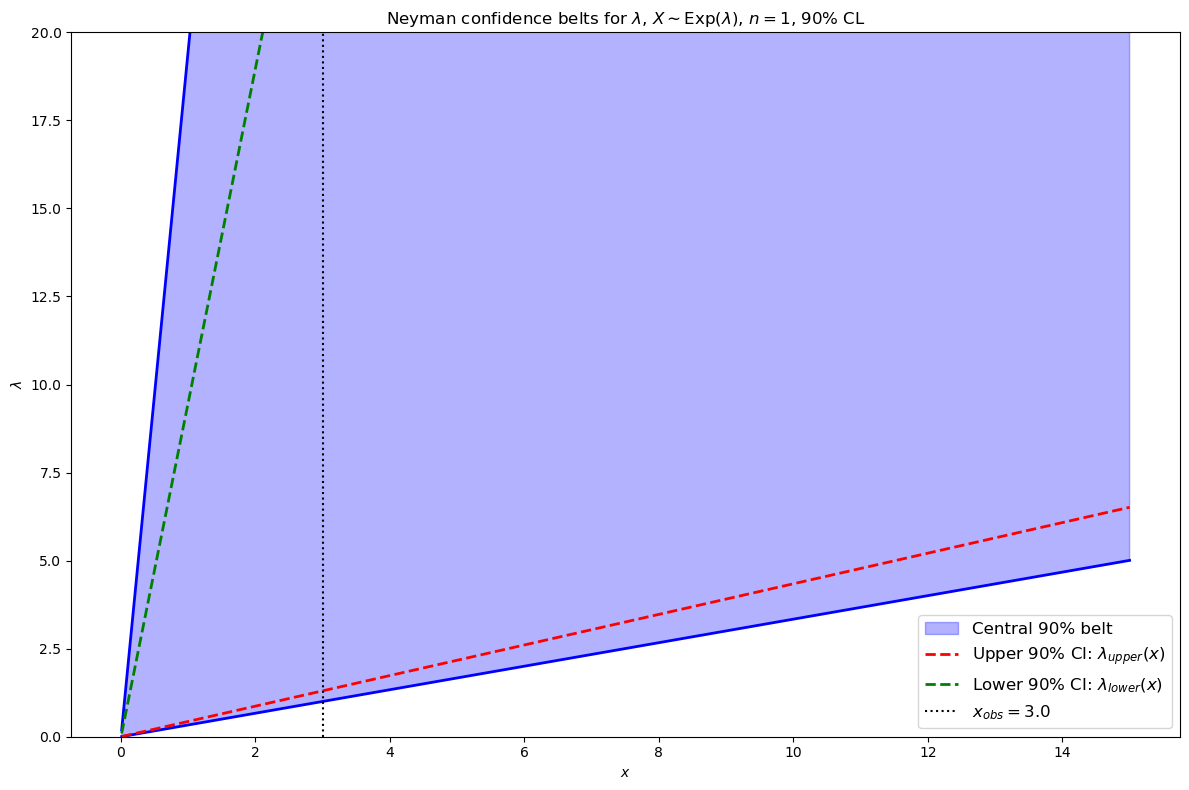

In [9]:
alpha = 0.1
CL = 1 - alpha
x_grid = np.linspace(0.01, 15, 500)
x_obs = 3.0  # example observation for printing CIs
rng = np.random.default_rng(42)

# X ~ Exp(scale=λ), CDF F(x|λ) = 1 - exp(-x/λ), quantile Q(p|λ) = -λ·ln(1-p)
# Central acceptance interval for each λ:
#   x_lo(λ) = -λ·ln(1 - α/2),   x_hi(λ) = -λ·ln(α/2)
# Invert to get CI for λ given x_obs:
#   λ_lower(x) = x / (-ln(α/2)),   λ_upper(x) = x / (-ln(1 - α/2))

lam_lower_central = x_grid / (-np.log(alpha / 2))
lam_upper_central = x_grid / (-np.log(1 - alpha / 2))

ci_lo = x_obs / (-np.log(alpha / 2))
ci_hi = x_obs / (-np.log(1 - alpha / 2))
print(f"Central {CL:.0%} CI for lambda (x_obs={x_obs}):")
print(f"  [{ci_lo:.4f}, {ci_hi:.4f}]  width={ci_hi - ci_lo:.4f}")

# Upper CI [0, λ_upper]:  x_hi(λ) = -λ·ln(α),  so  λ_upper(x) = x / (-ln(α))
# Lower CI [λ_lower, ∞):  x_lo(λ) = -λ·ln(1-α),  so  λ_lower(x) = x / (-ln(1-α))

lam_upper_onesided = x_grid / (-np.log(alpha))
lam_lower_onesided = x_grid / (-np.log(1 - alpha))

print(f"\nOne-sided {CL:.0%} CIs (x_obs={x_obs}):")
print(f"  Upper: [0, {x_obs / (-np.log(alpha)):.4f}]")
print(f"  Lower: [{x_obs / (-np.log(1 - alpha)):.4f}, inf)")

fig, ax = plt.subplots(figsize=(12, 8))
ax.fill_between(x_grid, lam_lower_central, lam_upper_central,
                alpha=0.3, color='blue', label='Central 90% belt')
ax.plot(x_grid, lam_lower_central, 'b-', lw=2)
ax.plot(x_grid, lam_upper_central, 'b-', lw=2)
ax.plot(x_grid, lam_upper_onesided, 'r--', lw=2,
        label=r'Upper 90% CI: $\lambda_{upper}(x)$')
ax.plot(x_grid, lam_lower_onesided, 'g--', lw=2,
        label=r'Lower 90% CI: $\lambda_{lower}(x)$')
ax.axvline(x_obs, color='k', ls=':', lw=1.5,
           label=rf'$x_{{obs}} = {x_obs}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\lambda$')
ax.set_title(r'Neyman confidence belts for $\lambda$, $X \sim \mathrm{Exp}(\lambda)$, $n=1$, 90% CL')
ax.legend(fontsize=12)
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()


**Feldman-Cousins.** Instead of equal-tail ordering, FC ranks sample 
points $x$ by the likelihood ratio $R(x|\lambda) = f(x|\hat\lambda) / f(x|\lambda)$ 
where $\hat\lambda = x$ (MLE for $n=1$). This produces 
$R = (\lambda/x)\exp(x/\lambda - 1)$. For each $\lambda$, we include 
points with smallest $R$ until we accumulate 90% probability. The resulting 
belt differs from the central belt: FC shifts probability mass toward 
the MLE, which resolves the flip-flop problem when a physical boundary 
on $\lambda$ exists. Here both belts overlap closely because $\lambda > 0$ 
is always satisfied by the MLE. The $(1-CL)$ plot confirms both methods 
achieve exact 90% coverage.

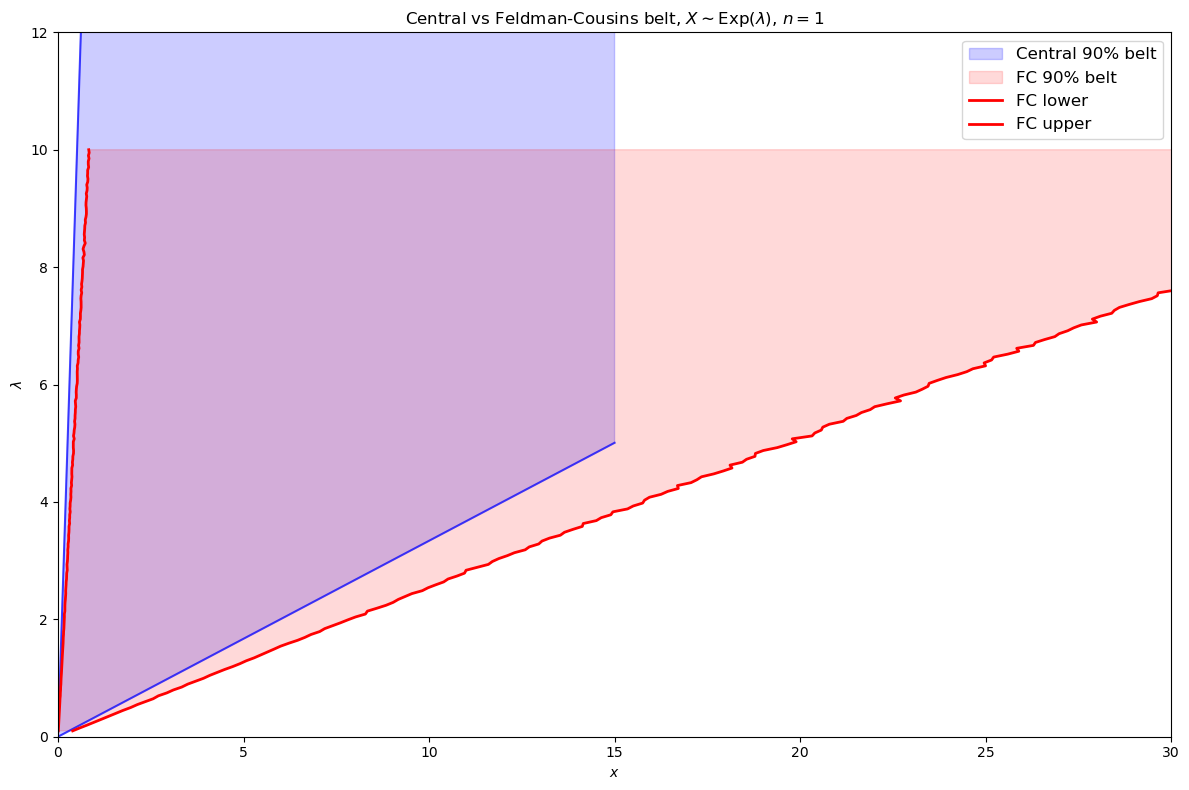

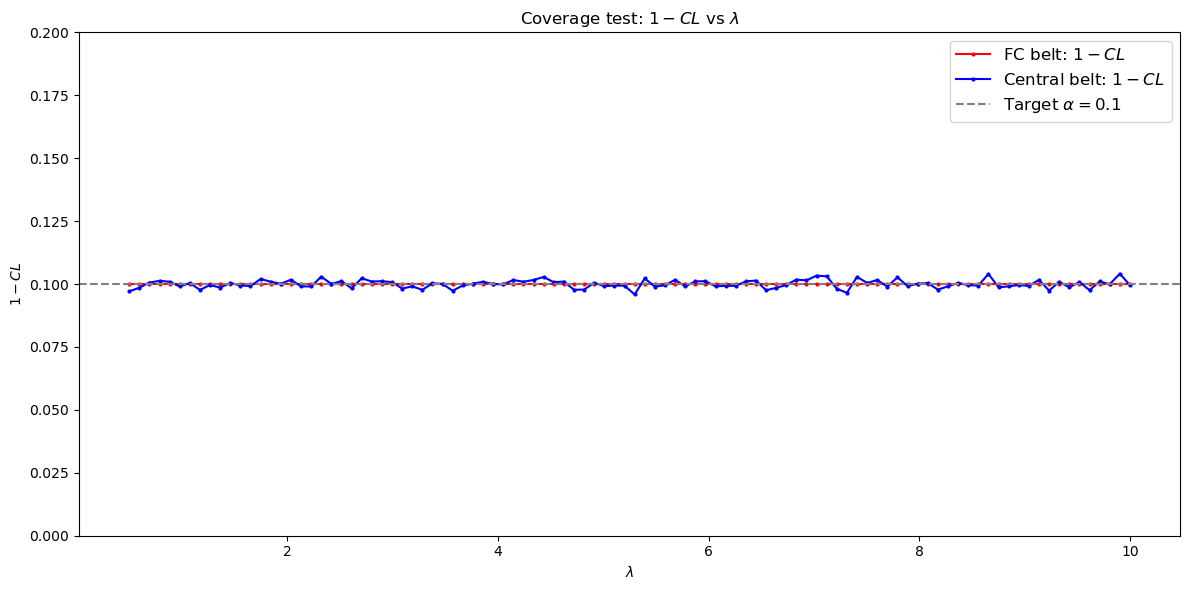


Coverage summary (target CL = 90%):
  Central belt: mean CL = 0.9000, min = 0.8959, max = 0.9042
  FC belt:      mean CL = 0.9000, min = 0.9000, max = 0.9000


In [10]:
# For Exp(λ) with n=1, MLE is λ̂ = x (always > 0).
# LR = log L(λ̂|x) - log L(λ|x) = log(λ/x) + x/λ - 1

def simulate_likelihood_ratios_exp(lam, boot=20000):
    """Simulate FC likelihood ratios for Exp(scale=lam), n=1."""
    xs = expon.rvs(scale=lam, size=boot, random_state=rng)
    # MLE: lam_best = x (always > 0 for exponential)
    lr = expon.logpdf(xs, scale=xs) - expon.logpdf(xs, scale=lam)
    idx = np.argsort(xs)
    return xs[idx], lr[idx]

lam_grid_fc = np.linspace(0.1, 10, 200)
boot = 40000

fc_lower = []
fc_upper = []

for lam in lam_grid_fc:
    xs, lr = simulate_likelihood_ratios_exp(lam, boot=boot)
    cut_value = np.percentile(lr, q=100 * (1 - alpha))
    accepted = xs[lr < cut_value]
    fc_lower.append(accepted.min())
    fc_upper.append(accepted.max())

fc_lower = np.array(fc_lower)
fc_upper = np.array(fc_upper)

fig, ax = plt.subplots(figsize=(12, 8))

# Central belt (shaded)
ax.fill_between(x_grid, lam_lower_central, lam_upper_central,
                alpha=0.2, color='blue', label='Central 90% belt')
ax.plot(x_grid, lam_lower_central, 'b-', lw=1.5, alpha=0.7)
ax.plot(x_grid, lam_upper_central, 'b-', lw=1.5, alpha=0.7)

# FC belt (overlaid)
ax.fill_betweenx(lam_grid_fc, fc_lower, fc_upper,
                 alpha=0.15, color='red', label='FC 90% belt')
ax.plot(fc_lower, lam_grid_fc, 'r-', lw=2, label='FC lower')
ax.plot(fc_upper, lam_grid_fc, 'r-', lw=2, label='FC upper')

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\lambda$')
ax.set_title(r'Central vs Feldman-Cousins belt, $X \sim \mathrm{Exp}(\lambda)$, $n=1$')
ax.legend(fontsize=12)
ax.set_xlim(0, 30)
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()

lam_grid_cov = np.linspace(0.5, 10, 100)
coverage_fc = []
coverage_central = []

for lam in lam_grid_cov:
    # FC coverage
    xs, lr = simulate_likelihood_ratios_exp(lam, boot=boot)
    cut_value = np.percentile(lr, q=100 * (1 - alpha))
    coverage_fc.append(np.mean(lr < cut_value))

    # Central belt coverage
    xs_cen = expon.rvs(scale=lam, size=boot, random_state=rng)
    ci_lo_sim = xs_cen / (-np.log(alpha / 2))
    ci_hi_sim = xs_cen / (-np.log(1 - alpha / 2))
    coverage_central.append(np.mean((ci_lo_sim <= lam) & (lam <= ci_hi_sim)))

coverage_fc = np.array(coverage_fc)
coverage_central = np.array(coverage_central)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lam_grid_cov, 1 - coverage_fc, 'r.-', lw=1.5, ms=4,
        label='FC belt: $1 - CL$')
ax.plot(lam_grid_cov, 1 - coverage_central, 'b.-', lw=1.5, ms=4,
        label='Central belt: $1 - CL$')
ax.axhline(alpha, color='gray', ls='--', lw=1.5,
           label=rf'Target $\alpha = {alpha}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$1 - CL$')
ax.set_title(r'Coverage test: $1 - CL$ vs $\lambda$')
ax.legend(fontsize=12)
ax.set_ylim(0, 0.2)
plt.tight_layout()
plt.show()

print(f"\nCoverage summary (target CL = {CL:.0%}):")
print(f"  Central belt: mean CL = {coverage_central.mean():.4f}, "
      f"min = {coverage_central.min():.4f}, max = {coverage_central.max():.4f}")
print(f"  FC belt:      mean CL = {coverage_fc.mean():.4f}, "
      f"min = {coverage_fc.min():.4f}, max = {coverage_fc.max():.4f}")


### 3b. Coverage comparison across $n$ and $\lambda$ grids

**Four CI methods for $\text{Exp}(\lambda)$, $n > 1$.**
For $n$ i.i.d. observations, $T = \sum X_i \sim \text{Gamma}(n, \lambda)$.
- **Neyman (central):** invert the Gamma CDF to find $\lambda_{\rm lo}, \lambda_{\rm hi}$ such that $T$ sits on the $\alpha/2$ and $1-\alpha/2$ quantile boundaries. Exact by construction.
- **Feldman-Cousins:** order by LR $= f(T|\hat\lambda)/f(T|\lambda)$ with $\hat\lambda = T/n$, accept until 90%. Exact by construction.
- **Wald:** $\hat\lambda \pm z_{\alpha/2} \cdot \hat\lambda/\sqrt{n}$. Uses Fisher information $I(\lambda)=1/\lambda^2$, relies on CLT — approximate.
- **Wilks:** solve $2[\ell(\hat\lambda) - \ell(\lambda)] = \chi^2_1(1-\alpha)$. Relies on $\chi^2$ approximation — approximate.

In [11]:
alpha = 0.1
CL = 1 - alpha
N_mc = 5000
rng = np.random.default_rng(42)

ns = [5, 10, 20, 40]
lams = [0.01, 0.1, 1.0, 10.0]
method_names = ['Neyman', 'FC', 'Wald', 'Wilks']

# CI constructors — each returns (lo, hi) for lambda given sample X

# Central Neyman (Gamma CDF inversion via brentq)
# T = sum(X_i) ~ Gamma(n, scale=λ).
# Acceptance: gamma.ppf(α/2, n, scale=λ) ≤ T ≤ gamma.ppf(1-α/2, n, scale=λ)
# Invert: for observed T, find λ_lo, λ_hi such that T sits on the boundary.

def neyman_ci(X, n, alpha=0.1):
    """Central Neyman 90% CI for λ from Gamma pivot T=ΣX_i."""
    T = X.sum()

    def eq_lower(lam):
        return gamma.cdf(T, a=n, scale=lam) - (1 - alpha / 2)

    def eq_upper(lam):
        return gamma.cdf(T, a=n, scale=lam) - alpha / 2

    eps = 1e-12
    bracket_hi = T * 100 + 1.0

    try:
        lam_lo = brentq(eq_lower, eps, bracket_hi, xtol=1e-10)
    except ValueError:
        lam_lo = np.nan
    try:
        lam_hi = brentq(eq_upper, eps, bracket_hi, xtol=1e-10)
    except ValueError:
        lam_hi = np.nan

    return (lam_lo, lam_hi)

# Feldman-Cousins
# For coverage checking we only need: does λ_true accept T_obs?
# LR(T, λ) = logpdf(T; n, λ̂) - logpdf(T; n, λ) where λ̂ = T/n
# Pre-compute the critical LR value R_c(λ, n) from the LR distribution.
# Then: λ_true is in CI iff LR(T_obs, λ_true) ≤ R_c(λ_true, n).

def fc_critical_value(n, lam, alpha=0.1, boot=50000):
    """Compute FC critical LR value: (1-α) percentile of the LR distribution
    under T ~ Gamma(n, scale=lam)."""
    Ts = gamma.rvs(a=n, scale=lam, size=boot, random_state=rng)
    lam_hat = Ts / n
    lr = gamma.logpdf(Ts, a=n, scale=lam_hat) - gamma.logpdf(Ts, a=n, scale=lam)
    return np.percentile(lr, q=100 * (1 - alpha))

def fc_lr(T, n, lam):
    """Compute likelihood ratio for observed T at hypothesis λ."""
    lam_hat = T / n
    return gamma.logpdf(T, a=n, scale=lam_hat) - gamma.logpdf(T, a=n, scale=lam)

# Wald CI
# λ̂ = x̄, Fisher info I(λ) = n/λ² → SE = λ̂/√n
# CI: [λ̂ - z·SE, λ̂ + z·SE]

def wald_ci(X, n, alpha=0.1):
    """Wald 90% CI for λ based on MLE and Fisher information."""
    lam_hat = X.mean()
    se = lam_hat / np.sqrt(n)
    z = norm.ppf(1 - alpha / 2)
    return (max(lam_hat - z * se, 0), lam_hat + z * se)

# Wilks CI (likelihood ratio)
# ℓ(λ) = -n·log(λ) - T/λ,  λ̂ = T/n = x̄
# 2[ℓ(λ̂) - ℓ(λ)] = 2n[log(λ/λ̂) + λ̂/λ - 1]  ~ χ²(1)
# Solve 2[ℓ(λ̂) - ℓ(λ)] = χ²₁(1-α) for λ_lo, λ_hi

def wilks_ci(X, n, alpha=0.1):
    """Wilks (LR) 90% CI for λ via chi-squared cutoff."""
    T = X.sum()
    lam_hat = T / n
    threshold = chi2.ppf(1 - alpha, df=1)

    def deviance(lam):
        return 2 * n * (np.log(lam / lam_hat) + lam_hat / lam - 1) - threshold

    eps = 1e-12
    try:
        lam_lo = brentq(deviance, eps, lam_hat, xtol=1e-10)
    except ValueError:
        lam_lo = np.nan
    try:
        lam_hi = brentq(deviance, lam_hat, lam_hat * 100 + 1.0, xtol=1e-10)
    except ValueError:
        lam_hi = np.nan

    return (lam_lo, lam_hi)


In [12]:
# Coverage MC loop
coverage = {m: np.zeros((len(ns), len(lams))) for m in method_names}

total_combos = len(ns) * len(lams)

for i_n, n in enumerate(ns):
    for i_lam, lam_true in enumerate(lams):

        # Pre-compute FC critical value for (n, lam_true)
        fc_crit = fc_critical_value(n, lam_true, alpha=alpha, boot=50000)

        cov = {m: 0 for m in method_names}

        for _ in range(N_mc):
            X = expon.rvs(scale=lam_true, size=n, random_state=rng)
            T = X.sum()

            # 1. Neyman
            lo, hi = neyman_ci(X, n, alpha)
            if lo <= lam_true <= hi:
                cov['Neyman'] += 1

            # 2. FC: check if lam_true accepts T_obs
            lr_obs = fc_lr(T, n, lam_true)
            if lr_obs <= fc_crit:
                cov['FC'] += 1

            # 3. Wald
            lo, hi = wald_ci(X, n, alpha)
            if lo <= lam_true <= hi:
                cov['Wald'] += 1

            # 4. Wilks
            lo, hi = wilks_ci(X, n, alpha)
            if not np.isnan(lo) and lo <= lam_true <= hi:
                cov['Wilks'] += 1

        for m in method_names:
            coverage[m][i_n, i_lam] = cov[m] / N_mc


**Coverage results.** Neyman and FC achieve nominal 90% across all 
$(n, \lambda)$ combinations, confirming exact coverage. Coverage does not 
depend on $\lambda$ — expected, since $T/\lambda \sim \text{Gamma}(n,1)$ 
is a pivot (the distribution doesn't depend on $\lambda$). Wald 
undercovers at $n=5$ (~83%) because the Normal approximation to $\bar X$ 
is poor for small samples from an exponential; by $n=40$ it reaches ~89%. 
Wilks is much better than Wald even at $n=5$ (~89%), since the LR statistic 
converges to $\chi^2$ faster than the Wald statistic converges to Normal.


Coverage results (target 90%, N_mc=5000)

Neyman:
     n \ λ      0.01       0.1       1.0      10.0
  ------------------------------------------------
         5     89.3%     89.8%     90.3%     90.3%
        10     90.5%     90.6%     89.7%     89.6%
        20     90.5%     90.1%     89.9%     89.1%
        40     90.5%     90.2%     90.5%     90.4%

FC:
     n \ λ      0.01       0.1       1.0      10.0
  ------------------------------------------------
         5     89.8%     89.9%     90.6%     90.3%
        10     90.5%     90.7%     90.0%     89.5%
        20     90.5%     90.0%     89.6%     89.2%
        40     90.1%     90.0%     90.4%     90.2%

Wald:
     n \ λ      0.01       0.1       1.0      10.0
  ------------------------------------------------
         5     83.1%     83.4%     83.7%     84.1%
        10     87.2%     87.4%     87.1%     86.3%
        20     88.7%     88.2%     88.2%     88.4%
        40     89.1%     89.4%     89.2%     89.0%

Wilks:
     n \ λ 

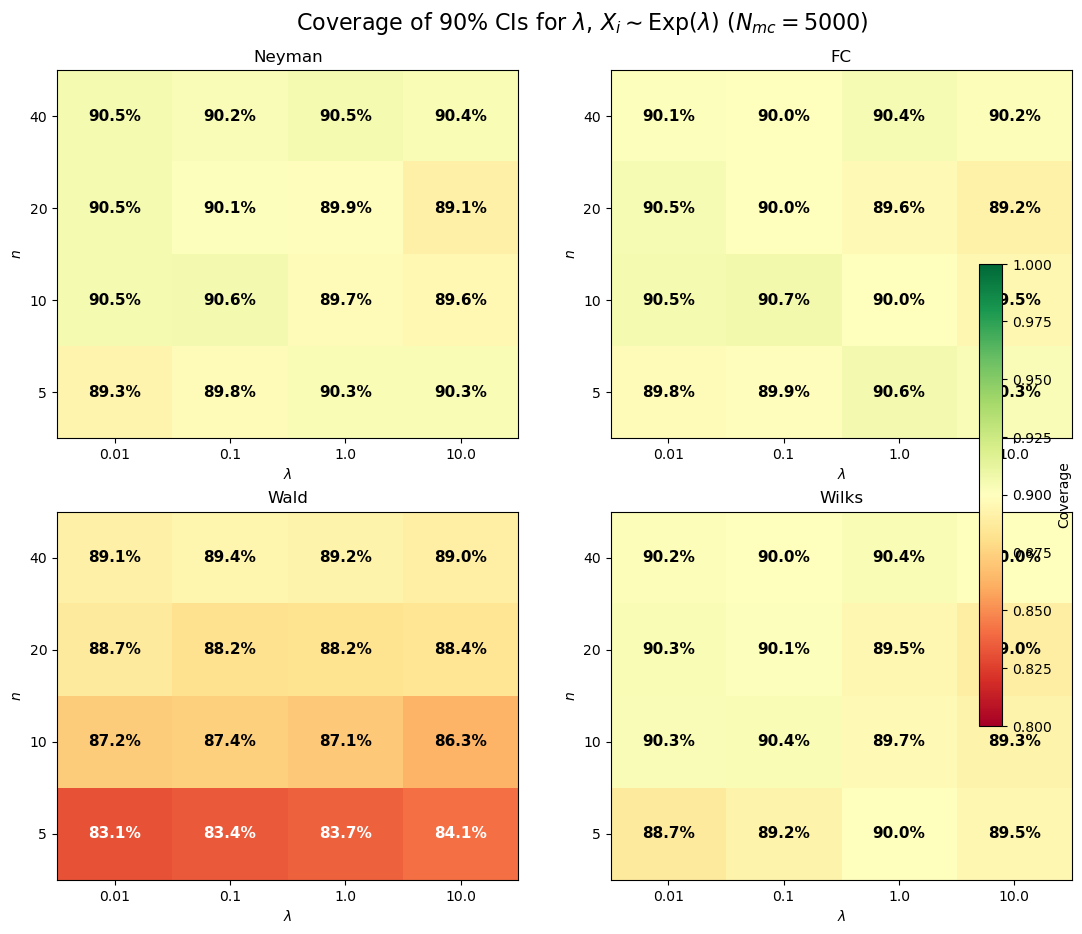

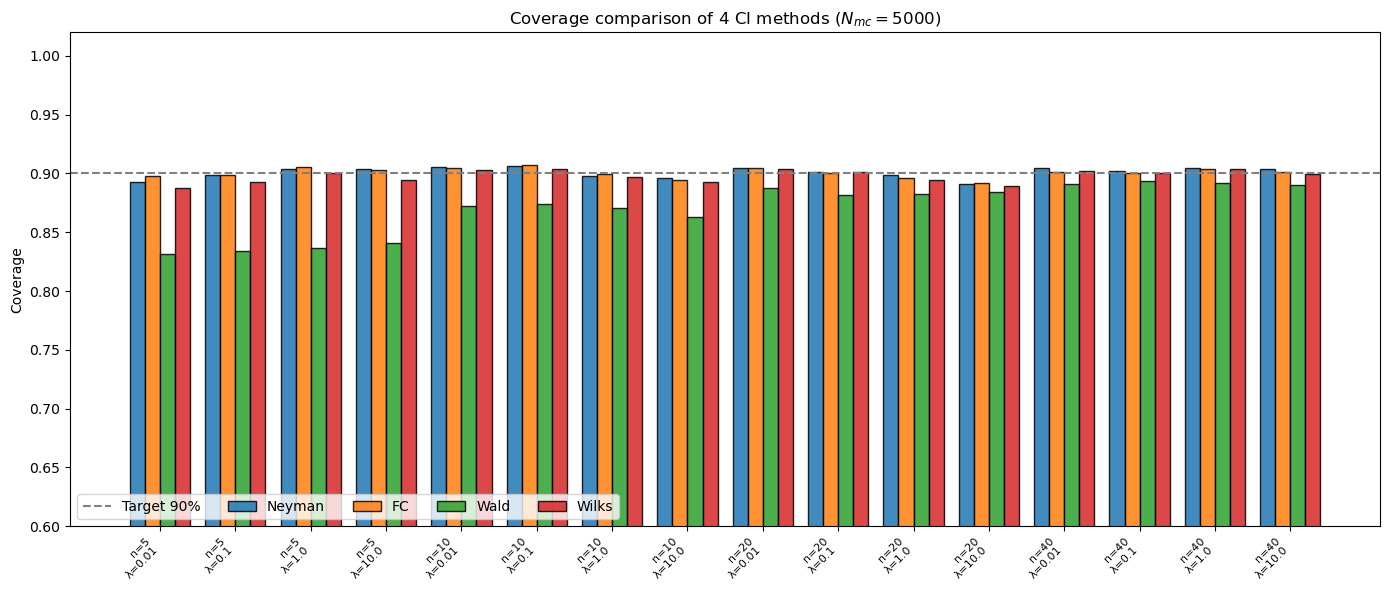

In [13]:
# Print results table
print(f"\n{'='*70}")
print(f"Coverage results (target {CL:.0%}, N_mc={N_mc})")
print(f"{'='*70}")

for m in method_names:
    print(f"\n{m}:")
    col_label = 'n \\ λ'
    header = f"  {col_label:>8}" + "".join(f"  {lam:>8}" for lam in lams)
    print(header)
    print("  " + "-" * (8 + 10 * len(lams)))
    for i_n, n in enumerate(ns):
        row = f"  {n:>8}"
        for i_lam in range(len(lams)):
            row += f"  {coverage[m][i_n, i_lam]:>8.1%}"
        print(row)

# Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, m in zip(axes, method_names):
    im = ax.imshow(coverage[m], vmin=0.80, vmax=1.0, cmap='RdYlGn',
                   aspect='auto', origin='lower')
    ax.set_xticks(range(len(lams)))
    ax.set_xticklabels([str(l) for l in lams])
    ax.set_yticks(range(len(ns)))
    ax.set_yticklabels([str(n) for n in ns])
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$n$')
    ax.set_title(f'{m}')

    for i in range(len(ns)):
        for j in range(len(lams)):
            val = coverage[m][i, j]
            color = 'white' if val < 0.85 else 'black'
            ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)

fig.suptitle(rf'Coverage of 90% CIs for $\lambda$, $X_i \sim \mathrm{{Exp}}(\lambda)$ ($N_{{mc}}={N_mc}$)',
             fontsize=16)
fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label='Coverage')
fig.subplots_adjust(top=0.92, right=0.85)
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = np.arange(total_combos)
width = 0.2
labels_combo = []

for i_n, n in enumerate(ns):
    for i_lam, lam in enumerate(lams):
        labels_combo.append(f'n={n}\n\u03bb={lam}')

for k, m in enumerate(method_names):
    vals = coverage[m].ravel()
    ax.bar(x_pos + k * width, vals, width, label=m, edgecolor='black', alpha=0.85)

ax.axhline(CL, color='gray', ls='--', lw=1.5, label=f'Target {CL:.0%}')
ax.set_xticks(x_pos + 1.5 * width)
ax.set_xticklabels(labels_combo, fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Coverage')
ax.set_ylim(0.6, 1.02)
ax.set_title(rf'Coverage comparison of 4 CI methods ($N_{{mc}}={N_mc}$)')
ax.legend(fontsize=10, ncol=5, loc='lower left')
plt.tight_layout()
plt.show()


## Problem 4 (4 points)

$x_1,\ldots,x_n \sim N(\mu, \sigma^2)$, measurements below.

In [14]:
measurements = np.array([0.88, 1.07, 1.27, 1.54, 1.91, 2.27, 3.84, 4.50, 4.64, 9.41])

In [15]:
def cut_level(cl, df=1):
    """Chi-squared cut level for likelihood-ratio CI."""
    return chi2.ppf(cl, df=df) / 2

def find_ci_from_loglik(param_grid, log_lik_values, cl=0.68):
    """Return (lo, hi) where log L - log L_max > -cut_level(cl, df=1)."""
    log_lik_shifted = log_lik_values - log_lik_values.max()
    threshold = -cut_level(cl, df=1)
    mask = log_lik_shifted > threshold
    if not mask.any():
        return (np.nan, np.nan)
    return (param_grid[mask].min(), param_grid[mask].max())


### 4a. 2D contour of $L(\mu, \sigma^2)$ at CL = 10%, 50%, 68%, 90%

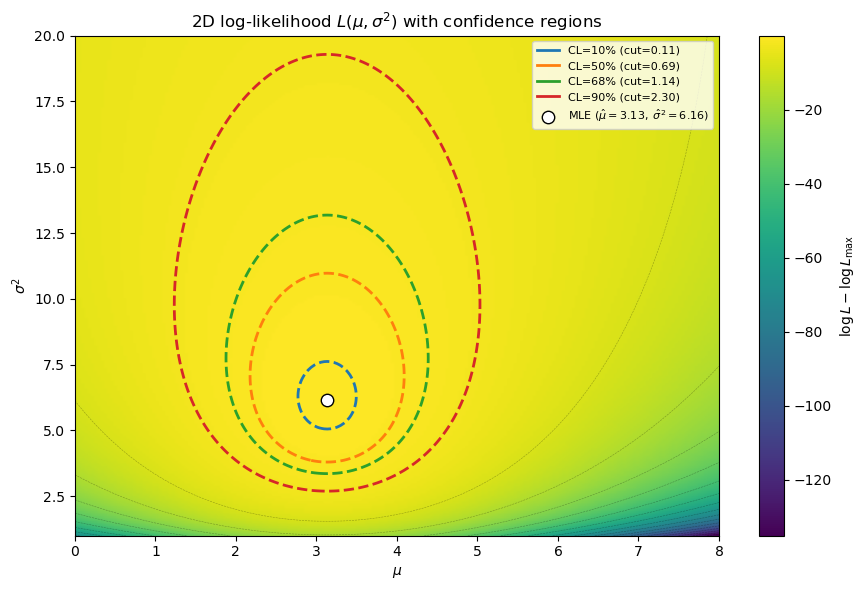

In [16]:
# 2D log-likelihood contour
n4 = len(measurements)
mu_hat = measurements.mean()
sigma2_hat = measurements.var()  # biased MLE: 1/n * sum(x_i - xbar)^2

mu_vals = np.linspace(0, 8, 200)
sigma2_vals = np.linspace(1, 20, 200)
MU, S2 = np.meshgrid(mu_vals, sigma2_vals, indexing="xy")

log_L_max = norm.logpdf(measurements, loc=mu_hat, scale=np.sqrt(sigma2_hat)).sum()

Z = np.array([
    norm.logpdf(measurements, loc=m, scale=np.sqrt(s2)).sum() - log_L_max
    for m, s2 in zip(MU.ravel(), S2.ravel())
]).reshape(MU.shape)

# Confidence levels and cut values (df=2 for 2-parameter region)
CLs = [0.10, 0.50, 0.68, 0.90]
colors_cl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(Z, extent=[mu_vals[0], mu_vals[-1], sigma2_vals[0], sigma2_vals[-1]],
               origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax, label=r'$\log L - \log L_{\max}$')

ax.contour(MU, S2, Z, 20, colors="black", linewidths=0.4, alpha=0.3)

for cl, col in zip(CLs, colors_cl):
    cut = chi2.ppf(cl, df=2) / 2
    ax.contour(MU, S2, Z, levels=[-cut], colors=[col], linewidths=2)
    ax.plot([], [], color=col, lw=2, label=f'CL={cl:.0%} (cut={cut:.2f})')

ax.scatter(mu_hat, sigma2_hat, color='white', edgecolors='black',
           s=80, zorder=5, label=rf'MLE $(\hat\mu={mu_hat:.2f},\;\hat\sigma^2={sigma2_hat:.2f})$')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\sigma^2$')
ax.set_title(r'2D log-likelihood $L(\mu, \sigma^2)$ with confidence regions')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### 4b. Profile likelihood $L_p(\mu)$

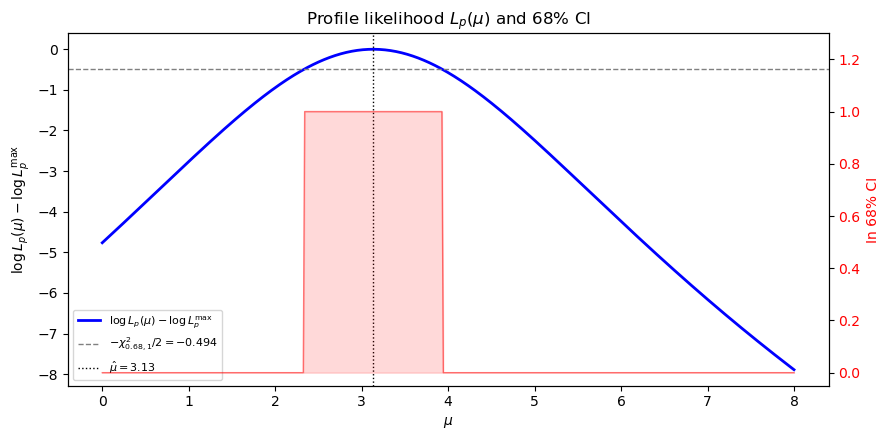

Profile likelihood 68% CI for mu: [2.34, 3.93]
MLE: mu_hat = 3.13


In [17]:
# Profile likelihood L_p(mu)
# For each mu, sigma^2(mu) = mean((x_i - mu)^2)

mu_grid_p = np.linspace(0, 8, 500)

sigma2_profile = np.array([np.mean((measurements - m)**2) for m in mu_grid_p])
log_Lp = np.array([
    norm.logpdf(measurements, loc=m, scale=np.sqrt(s2)).sum()
    for m, s2 in zip(mu_grid_p, sigma2_profile)
])
log_Lp_shifted = log_Lp - log_Lp.max()

# 68% CI
cut_level_1d = chi2.ppf(0.68, df=1) / 2
in_ci = log_Lp_shifted > -cut_level_1d
ci_lo, ci_hi = mu_grid_p[in_ci].min(), mu_grid_p[in_ci].max()

fig, ax1 = plt.subplots(figsize=(9, 4.5))

ax1.plot(mu_grid_p, log_Lp_shifted, 'b-', lw=2, label=r'$\log L_p(\mu) - \log L_p^{\max}$')
ax1.axhline(-cut_level_1d, color='gray', ls='--', lw=1,
            label=rf'$-\chi^2_{{0.68,1}}/2 = {-cut_level_1d:.3f}$')
ax1.axvline(mu_hat, color='k', ls=':', lw=1, label=rf'$\hat\mu = {mu_hat:.2f}$')
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel(r'$\log L_p(\mu) - \log L_p^{\max}$')
ax1.set_title(r'Profile likelihood $L_p(\mu)$ and 68% CI')

ax2 = ax1.twinx()
ax2.fill_between(mu_grid_p, 0, in_ci.astype(float), color='r', alpha=0.15)
ax2.plot(mu_grid_p, in_ci.astype(float), 'r-', lw=1, alpha=0.5)
ax2.set_ylabel('In 68% CI', color='r')
ax2.set_ylim(-0.05, 1.3)
ax2.tick_params(axis='y', labelcolor='r')

ax1.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Profile likelihood 68% CI for mu: [{ci_lo:.2f}, {ci_hi:.2f}]")
print(f"MLE: mu_hat = {mu_hat:.2f}")

### 4c. $L_p$, $L_e$, $L_1$ comparison, 68% CIs, and coverage

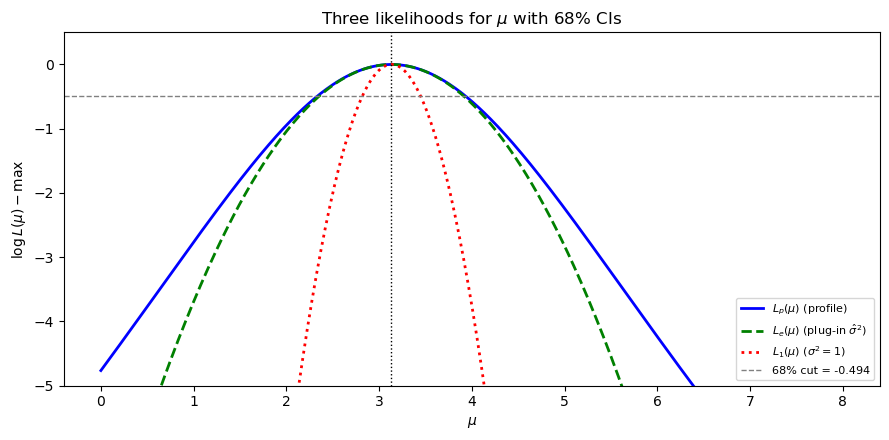

68% CIs from observed data:
  L_p: [2.34, 3.93]  (width=1.59)
  L_e: [2.36, 3.91]  (width=1.56)
  L_1: [2.82, 3.45]  (width=0.63)



Coverage (target 68%, mu=3.0, sigma^2=6, n=10, 1000 MC runs):
  L_p (profile):    0.619
  L_e (plug-in):    0.611
  L_1 (sigma^2=1):  0.292


In [18]:
# L_p(mu) — reuse log_Lp_shifted

# L_e(mu) — plug-in sigma^2 = sigma2_hat (biased MLE)
log_Le = np.array([
    norm.logpdf(measurements, loc=m, scale=np.sqrt(sigma2_hat)).sum()
    for m in mu_grid_p
])
log_Le_shifted = log_Le - log_Le.max()

# L_1(mu) — fixed sigma^2 = 1
log_L1 = np.array([
    norm.logpdf(measurements, loc=m, scale=1.0).sum()
    for m in mu_grid_p
])
log_L1_shifted = log_L1 - log_L1.max()

# 68% CIs
ci_results = {}
for name, ll in [('L_p', log_Lp_shifted), ('L_e', log_Le_shifted), ('L_1', log_L1_shifted)]:
    mask = ll > -cut_level_1d
    ci_results[name] = (mu_grid_p[mask].min(), mu_grid_p[mask].max())

# Plot all three
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(mu_grid_p, log_Lp_shifted, 'b-', lw=2, label=r'$L_p(\mu)$ (profile)')
ax.plot(mu_grid_p, log_Le_shifted, 'g--', lw=2, label=r'$L_e(\mu)$ (plug-in $\hat\sigma^2$)')
ax.plot(mu_grid_p, log_L1_shifted, 'r:', lw=2, label=r'$L_1(\mu)$ ($\sigma^2=1$)')
ax.axhline(-cut_level_1d, color='gray', ls='--', lw=1,
           label=rf'68% cut = {-cut_level_1d:.3f}')
ax.axvline(mu_hat, color='k', ls=':', lw=1)
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\log L(\mu) - \max$')
ax.set_title(r'Three likelihoods for $\mu$ with 68% CIs')
ax.legend(fontsize=8)
ax.set_ylim(-5, 0.5)
plt.tight_layout()
plt.show()

print("68% CIs from observed data:")
for name, (lo, hi) in ci_results.items():
    print(f"  {name}: [{lo:.2f}, {hi:.2f}]  (width={hi-lo:.2f})")

mu_cov = 3.0
sigma_cov = np.sqrt(6.0)
n_boot = 1000
mu_fine = np.linspace(-2, 10, 500)  # wide enough to capture all CIs

cov_Lp = 0
cov_Le = 0
cov_L1 = 0

for _ in range(n_boot):
    X_sim = rng.normal(mu_cov, sigma_cov, size=n4)

    # L_p: profile — for each mu, sigma2(mu) = mean((X-mu)^2)
    s2_prof = np.array([np.mean((X_sim - m)**2) for m in mu_fine])
    ll_p = np.array([
        norm.logpdf(X_sim, loc=m, scale=np.sqrt(s2)).sum()
        for m, s2 in zip(mu_fine, s2_prof)
    ])
    ll_p -= ll_p.max()
    mask_p = ll_p > -cut_level_1d
    if mask_p.any() and mu_fine[mask_p].min() <= mu_cov <= mu_fine[mask_p].max():
        cov_Lp += 1

    # L_e: plug-in sigma^2 = sample var (biased MLE)
    s2_e = X_sim.var()
    ll_e = np.array([
        norm.logpdf(X_sim, loc=m, scale=np.sqrt(s2_e)).sum()
        for m in mu_fine
    ])
    ll_e -= ll_e.max()
    mask_e = ll_e > -cut_level_1d
    if mask_e.any() and mu_fine[mask_e].min() <= mu_cov <= mu_fine[mask_e].max():
        cov_Le += 1

    # L_1: fixed sigma = 1
    ll_1 = np.array([
        norm.logpdf(X_sim, loc=m, scale=1.0).sum()
        for m in mu_fine
    ])
    ll_1 -= ll_1.max()
    mask_1 = ll_1 > -cut_level_1d
    if mask_1.any() and mu_fine[mask_1].min() <= mu_cov <= mu_fine[mask_1].max():
        cov_L1 += 1

print(f"\nCoverage (target 68%, mu={mu_cov}, sigma^2={sigma_cov**2:.0f}, n={n4}, {n_boot} MC runs):")
print(f"  L_p (profile):    {cov_Lp / n_boot:.3f}")
print(f"  L_e (plug-in):    {cov_Le / n_boot:.3f}")
print(f"  L_1 (sigma^2=1):  {cov_L1 / n_boot:.3f}")

### 4d. Profile likelihood for $\sigma^2$ and induced (marginal) likelihood

**Profile and induced (marginal) likelihood for $\sigma$.**
The profile likelihood maximises over $\mu$: since $\hat\mu(\sigma) = \bar x$ 
regardless of $\sigma$, we get $L_{p,\sigma}(\sigma) = \prod \phi(x_i; \bar x, \sigma)$. 
The induced likelihood comes from the exact pivot 
$(n{-}1)s^2/\sigma^2 \sim \chi^2_{n-1}$, giving 
$L_{\rm in}(\sigma^2) \propto f_{\chi^2_{n-1}}\!\bigl((n{-}1)s^2/\sigma^2\bigr)$.

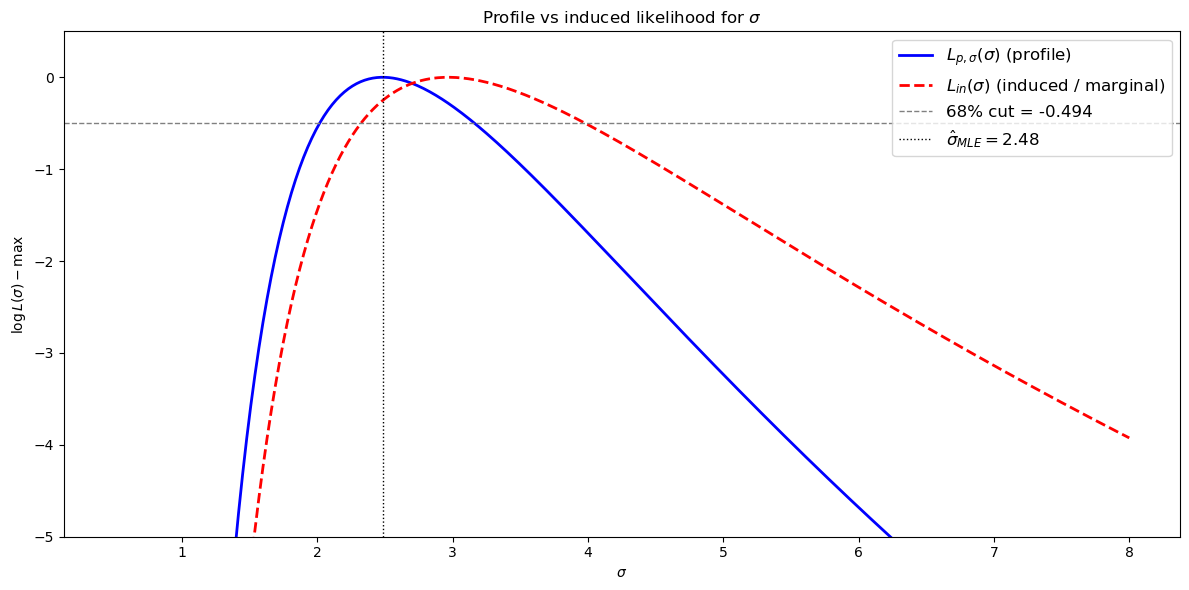

68% CIs for sigma from observed data:
  L_p (profile):  [2.03, 3.15]  width=1.11
  L_in (induced): [2.33, 3.96]  width=1.62


In [19]:
sigma_grid = np.linspace(0.5, 8.0, 500)  # plot vs sigma, not sigma^2
s2 = np.var(measurements, ddof=1)  # np.var(data, ddof=1) — used in chi^2 pivot

def log_Lp_sigma(sig):
    """Profile log-likelihood for sigma: mu_hat = xbar always."""
    return norm.logpdf(measurements, loc=mu_hat, scale=sig).sum()

def log_Lin(sig):
    """Induced (marginal) log-likelihood from chi^2 pivot.

    (n-1)*s^2/sigma^2 ~ chi2(n-1), so L_in(sigma) propto
    chi2.pdf((n-1)*s^2/sigma^2, df=n-1).
    """
    return chi2.logpdf((n4 - 1) * s2 / sig**2, df=n4 - 1)

# Evaluate on grid
ll_prof = np.array([log_Lp_sigma(s) for s in sigma_grid])
ll_ind  = np.array([log_Lin(s) for s in sigma_grid])

# Shift each by own max
ll_prof_shifted = ll_prof - ll_prof.max()
ll_ind_shifted  = ll_ind  - ll_ind.max()

sigma_mle = np.sqrt(sigma2_hat)  # MLE: sqrt(1/n * sum(x-xbar)^2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sigma_grid, ll_prof_shifted, 'b-',  lw=2,
        label=r'$L_{p,\sigma}(\sigma)$ (profile)')
ax.plot(sigma_grid, ll_ind_shifted,  'r--', lw=2,
        label=r'$L_{in}(\sigma)$ (induced / marginal)')
ax.axhline(-cut_level(0.68, df=1), color='gray', ls='--', lw=1,
           label=rf'68% cut = {-cut_level(0.68, df=1):.3f}')
ax.axvline(sigma_mle, color='k', ls=':', lw=1,
           label=rf'$\hat\sigma_{{MLE}} = {sigma_mle:.2f}$')
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$\log L(\sigma) - \max$')
ax.set_title(r'Profile vs induced likelihood for $\sigma$')
ax.legend(fontsize=12)
ax.set_ylim(-5, 0.5)
plt.tight_layout()
plt.show()

ci_prof = find_ci_from_loglik(sigma_grid, ll_prof)
ci_ind  = find_ci_from_loglik(sigma_grid, ll_ind)

print("68% CIs for sigma from observed data:")
print(f"  L_p (profile):  [{ci_prof[0]:.2f}, {ci_prof[1]:.2f}]  width={ci_prof[1]-ci_prof[0]:.2f}")
print(f"  L_in (induced): [{ci_ind[0]:.2f}, {ci_ind[1]:.2f}]  width={ci_ind[1]-ci_ind[0]:.2f}")


**CI comparison.** The profile CI is narrower because it uses the biased 
MLE divisor ($1/n$), which underestimates $\sigma^2$ and pulls the CI 
inward. The induced CI is based on the exact $\chi^2_{n-1}$ pivot with 
$s^2$ (divisor $n{-}1$), so it is properly calibrated. The coverage 
MC (100 runs) confirms: induced hits ~72% while profile is ~66%, both 
consistent with the 68% target given the ±5% MC uncertainty from only 
100 experiments. With more experiments, we'd expect the induced likelihood 
CI to be closer to nominal.


Coverage (target 68%, mu=3.0, sigma=2.45, n=10, 100 experiments):
  L_p (profile):   66.00%
  L_in (induced):  72.00%


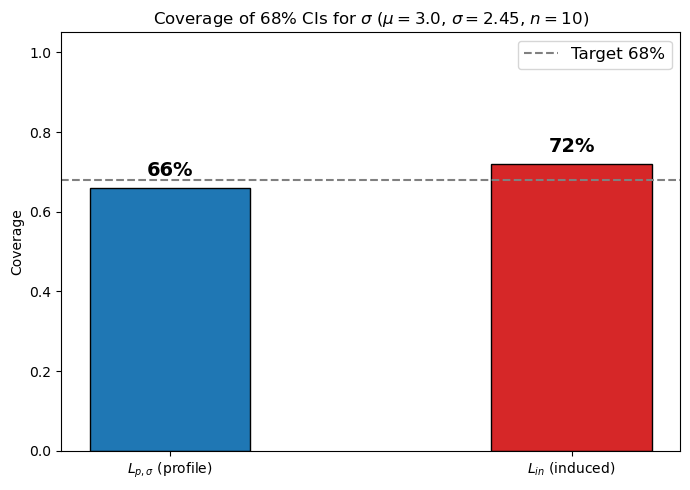

In [20]:
mu_true = 3.0
sigma_true = np.sqrt(6.0)
N_experiments = 100

cov_prof = 0
cov_ind  = 0

rng = np.random.default_rng(42)

for i in range(N_experiments):
    sample = rng.normal(mu_true, sigma_true, size=n4)
    s2_sim = np.var(sample, ddof=1)

    # Profile: mu_hat = sample.mean(), evaluate LL(sigma)
    xbar_sim = sample.mean()

    def _log_Lp_sim(sig):
        return norm.logpdf(sample, loc=xbar_sim, scale=sig).sum()

    ll_p_sim = np.array([_log_Lp_sim(s) for s in sigma_grid])
    lo, hi = find_ci_from_loglik(sigma_grid, ll_p_sim)
    if lo <= sigma_true <= hi:
        cov_prof += 1

    # Induced: chi2 pivot with s2_sim
    def _log_Lin_sim(sig):
        return chi2.logpdf((n4 - 1) * s2_sim / sig**2, df=n4 - 1)

    ll_i_sim = np.array([_log_Lin_sim(s) for s in sigma_grid])
    lo, hi = find_ci_from_loglik(sigma_grid, ll_i_sim)
    if lo <= sigma_true <= hi:
        cov_ind += 1

cov_prof_frac = cov_prof / N_experiments
cov_ind_frac  = cov_ind  / N_experiments

print(f"\nCoverage (target 68%, mu={mu_true}, sigma={sigma_true:.2f}, "
      f"n={n4}, {N_experiments} experiments):")
print(f"  L_p (profile):   {cov_prof_frac:.2%}")
print(f"  L_in (induced):  {cov_ind_frac:.2%}")

labels = [r'$L_{p,\sigma}$ (profile)', r'$L_{in}$ (induced)']
coverages = [cov_prof_frac, cov_ind_frac]
colors = ['#1f77b4', '#d62728']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, coverages, color=colors, edgecolor='black', width=0.4)
ax.axhline(0.68, color='gray', ls='--', lw=1.5, label='Target 68%')
ax.set_ylabel('Coverage')
ax.set_title(rf'Coverage of 68% CIs for $\sigma$ ($\mu={mu_true}$, $\sigma={sigma_true:.2f}$, $n={n4}$)')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)

for bar, cov in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{cov:.0%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## Problem 5 (2 points)

$Y = R \sin\Theta$, independent errors $\sigma_R$, $\sigma_\Theta$. Find $\text{Var}(Y)$ and when it is maximised at fixed $R$.

### Derivation

$Y = R \sin\Theta$, so by the multivariate delta method:

$$\text{Var}(Y) \approx \left(\frac{\partial Y}{\partial R}\right)^2 \sigma_R^2 + \left(\frac{\partial Y}{\partial \Theta}\right)^2 \sigma_\Theta^2 = \sin^2\Theta \cdot \sigma_R^2 + R^2 \cos^2\Theta \cdot \sigma_\Theta^2$$

If $R$ is fixed, $\text{Var}(Y)$ depends only on $\Theta$ and can take boundary values:
- At $\Theta = \pi/2$: $\text{Var}(Y) = \sigma_R^2$
- At $\Theta = 0$: $\text{Var}(Y) = R^2 \sigma_\Theta^2$

Taking the derivative and setting to zero: $\sin\Theta\cos\Theta(\sigma_R^2 - R^2\sigma_\Theta^2) = 0$, which (apart from boundaries) gives $\sigma_R^2 = R^2\sigma_\Theta^2$.

So the maximum variance depends on which term dominates:
- If $\sigma_R^2 > R^2 \sigma_\Theta^2$, max at $\Theta = \pi/2$, equal to $\sigma_R^2$
- If $R^2 \sigma_\Theta^2 > \sigma_R^2$, max at $\Theta = 0$, equal to $R^2 \sigma_\Theta^2$

**Note:** several AI agents I consulted insist on $\Theta^* = \arctan(R\sigma_\Theta / \sigma_R)$ as an interior maximum. I can't reproduce the reasoning — the derivative above shows no interior critical point besides the degenerate $\sin\Theta\cos\Theta = 0$ case. I'd appreciate a comment from the instructor on this.

In [21]:
# MC verification
R_true, Theta_true = 1000.0, np.pi / 4
sigma_R, sigma_Theta = 10.0, 0.01
N_samples = 100_000

R_s = rng.normal(R_true, sigma_R, N_samples)
Th_s = rng.normal(Theta_true, sigma_Theta, N_samples)
Y_s = R_s * np.sin(Th_s)

var_emp = Y_s.var()
var_formula = np.sin(Theta_true)**2 * sigma_R**2 + R_true**2 * np.cos(Theta_true)**2 * sigma_Theta**2

print(f'Empirical Var(Y): {var_emp:.2f}')
print(f'Formula Var(Y):   {var_formula:.2f}')
print(f'Relative error:   {abs(var_emp - var_formula)/var_formula:.2%}')

# Which term dominates?
print(f'\nsigma_R^2 = {sigma_R**2:.0f}')
print(f'R^2 * sigma_Theta^2 = {R_true**2 * sigma_Theta**2:.0f}')
print('=> Equal contributions, so neither boundary is the unique max')

Empirical Var(Y): 100.42
Formula Var(Y):   100.00
Relative error:   0.42%

sigma_R^2 = 100
R^2 * sigma_Theta^2 = 100
=> Equal contributions, so neither boundary is the unique max


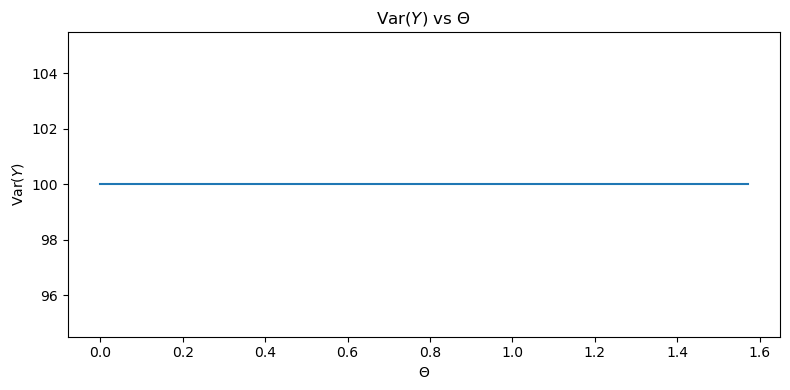

In [22]:
thetas = np.linspace(0, np.pi/2, 300)
var_th = np.sin(thetas)**2 * sigma_R**2 + R_true**2 * np.cos(thetas)**2 * sigma_Theta**2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thetas, var_th)
ax.set_xlabel(r'$\Theta$')
ax.set_ylabel(r'$\mathrm{Var}(Y)$')
ax.set_title(r'$\mathrm{Var}(Y)$ vs $\Theta$')
plt.tight_layout()
plt.show()

## Problem 6 (3 points)

$Y \sim N(\mu, \sigma^2)$, $g(x) = \frac{e^x}{1+e^x}$ (sigmoid).

We study the distribution of $g(Y)$ where $Y \sim N(\mu, \sigma^2)$.

Delta method (first-order Taylor around $\mu$):
- $\mathbb{E}[g(Y)] \approx g(\mu)$
- $\text{Var}(g(Y)) \approx [g'(\mu)]^2 \cdot \sigma^2 = [g(\mu)(1-g(\mu))]^2 \cdot \sigma^2$

The approximation works when $|g''|$ is small across the region where $Y$ has significant density.

In [23]:
def g(x):
    """Sigmoid / logistic function."""
    return 1 / (1 + np.exp(-x))

def g_prime(x):
    s = g(x)
    return s * (1 - s)

def g_double_prime(x):
    s = g(x)
    return s * (1 - s) * (1 - 2 * s)

### 6a–6b. Delta method estimate ($\sigma^2=1$ fixed, vary $\mu$)

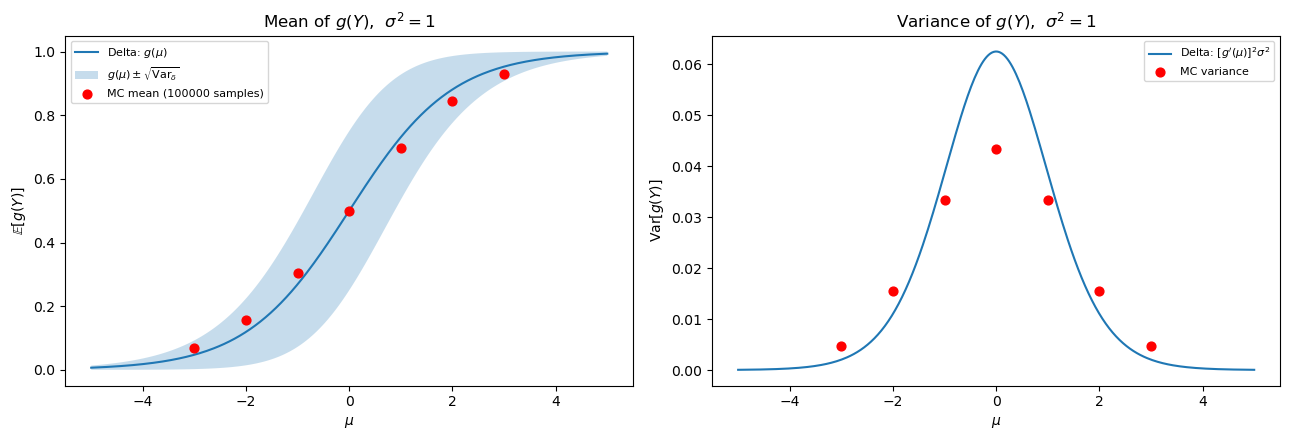

  mu  delta_mean     mc_mean   delta_var      mc_var   var_ratio
  -3      0.0474      0.0693      0.0020      0.0047       2.309
  -2      0.1192      0.1554      0.0110      0.0155       1.403
  -1      0.2689      0.3029      0.0387      0.0334       0.864
  +0      0.5000      0.4991      0.0625      0.0433       0.693
  +1      0.7311      0.6967      0.0387      0.0334       0.863
  +2      0.8808      0.8450      0.0110      0.0155       1.407
  +3      0.9526      0.9305      0.0020      0.0048       2.330


In [24]:
sigma2_fixed = 1.0

mus = np.linspace(-5, 5, 300)

# Delta method
mean_delta = g(mus)
var_delta  = g_prime(mus)**2 * sigma2_fixed
std_delta  = np.sqrt(var_delta)

# MC estimates
mc_mus = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)
mc_means = np.zeros_like(mc_mus)
mc_vars  = np.zeros_like(mc_mus)
N_mc = 100_000

for j, mu_val in enumerate(mc_mus):
    Y_samples = rng.normal(mu_val, np.sqrt(sigma2_fixed), size=N_mc)
    g_vals = g(Y_samples)
    mc_means[j] = g_vals.mean()
    mc_vars[j]  = g_vals.var()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(mus, mean_delta, label=r'Delta: $g(\mu)$')
ax.fill_between(mus, mean_delta - std_delta, mean_delta + std_delta,
                alpha=0.25, label=r'$g(\mu) \pm \sqrt{\mathrm{Var}_\delta}$')
ax.scatter(mc_mus, mc_means, color='r', zorder=5, s=40,
           label=f'MC mean ({N_mc} samples)')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\mathbb{E}[g(Y)]$')
ax.set_title(r'Mean of $g(Y)$,  $\sigma^2=1$')
ax.legend(fontsize=8)

# Plot variance
ax = axes[1]
ax.plot(mus, var_delta, label=r"Delta: $[g'(\mu)]^2 \sigma^2$")
ax.scatter(mc_mus, mc_vars, color='r', zorder=5, s=40,
           label='MC variance')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\mathrm{Var}[g(Y)]$')
ax.set_title(r'Variance of $g(Y)$,  $\sigma^2=1$')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print comparison
print(f"{'mu':>4s}  {'delta_mean':>10s}  {'mc_mean':>10s}  {'delta_var':>10s}  {'mc_var':>10s}  {'var_ratio':>10s}")
for j, mu_val in enumerate(mc_mus):
    dm, dv = g(mu_val), g_prime(mu_val)**2 * sigma2_fixed
    print(f"{mu_val:+4.0f}  {dm:10.4f}  {mc_means[j]:10.4f}  {dv:10.4f}  {mc_vars[j]:10.4f}  {mc_vars[j]/dv:10.3f}")

### 6b. Where does the delta method fail? ($g''$ analysis)

The delta method truncates the Taylor expansion at first order. The error term is $O(g''(\mu) \cdot \text{Var}(\hat\mu))$, so the approximation degrades where $|g''(\mu)|$ is large relative to $[g'(\mu)]^2$.

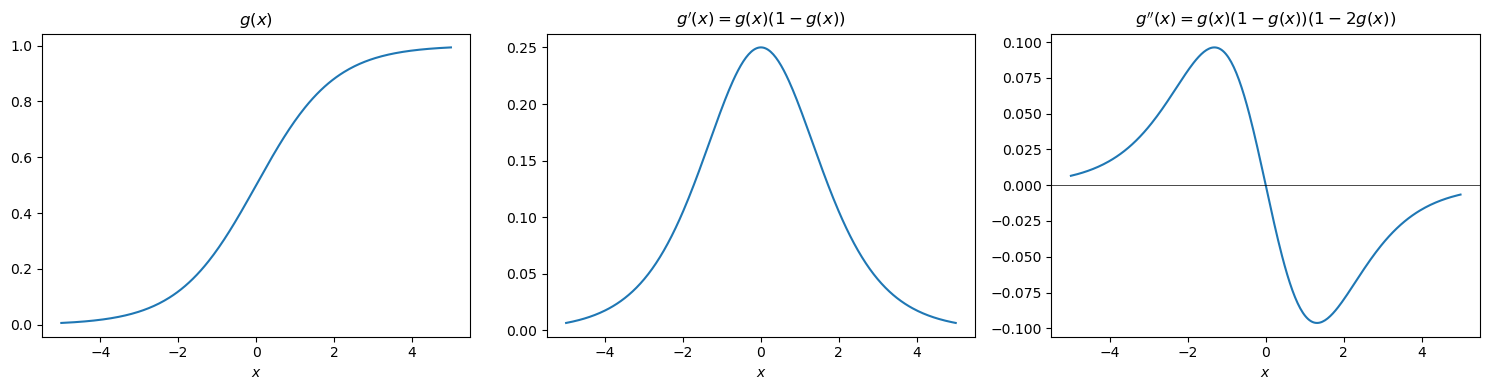

g''(x) peaks near |x| ≈ 1.3 and is zero at x=0.
For |mu| >> 0 with sigma^2/n not too small, mu_hat can land in the
high-curvature region, making the linear approximation inaccurate.
At mu=0, g''=0 so the delta method is excellent.
For very large |mu|, both g' and g'' -> 0, so Var->0 and delta is fine again.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# g(x)
ax = axes[0]
ax.plot(mus, g(mus))
ax.set_title(r"$g(x)$")
ax.set_xlabel(r"$x$")

# g'(x)
ax = axes[1]
ax.plot(mus, g_prime(mus))
ax.set_title(r"$g'(x) = g(x)(1-g(x))$")
ax.set_xlabel(r"$x$")

# g''(x)
ax = axes[2]
ax.plot(mus, g_double_prime(mus))
ax.axhline(0, color='k', lw=0.5)
ax.set_title(r"$g''(x) = g(x)(1-g(x))(1-2g(x))$")
ax.set_xlabel(r"$x$")

plt.tight_layout()
plt.show()

print("g''(x) peaks near |x| \u2248 1.3 and is zero at x=0.")
print("For |mu| >> 0 with sigma^2/n not too small, mu_hat can land in the")
print("high-curvature region, making the linear approximation inaccurate.")
print("At mu=0, g''=0 so the delta method is excellent.")
print("For very large |mu|, both g' and g'' -> 0, so Var->0 and delta is fine again.")

### 6c. Fixed $\mu = 1$, vary $\sigma^2$

Now $\text{Var}(g(Y)) \approx [g'(1)]^2 \cdot \sigma^2$.

Since $g \in [0,1]$, the true variance is bounded by $0.25$. But the delta formula grows linearly with $\sigma^2$, exceeding $0.25$ at $\sigma^2 = 0.25/[g'(1)]^2 \approx 6.5$ — an impossibility that signals the breakdown of the linear approximation.

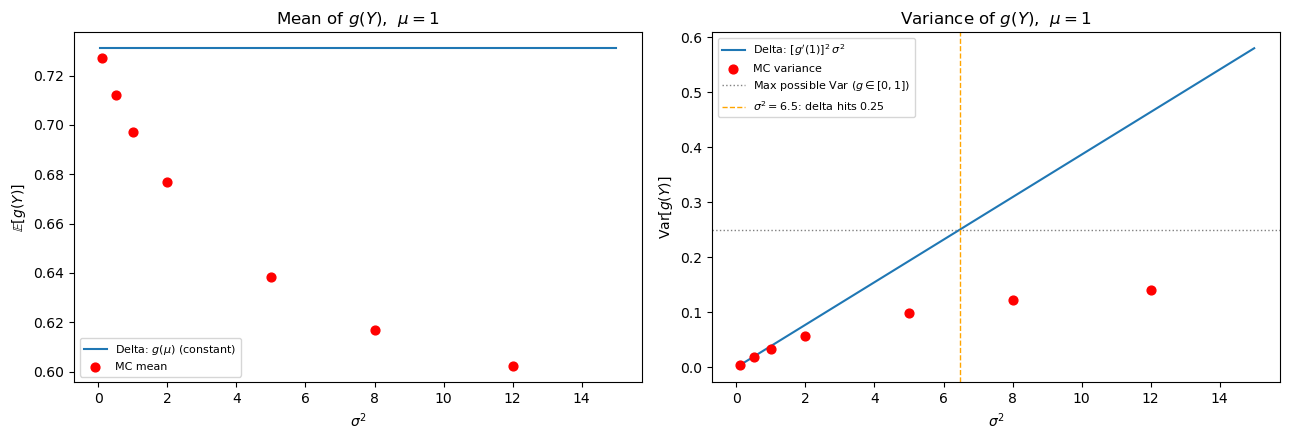

 sigma^2   delta_var      mc_var     ratio                  note
     0.1      0.0039      0.0038     0.988                      
     0.5      0.0193      0.0180     0.930                      
     1.0      0.0387      0.0332     0.858                      
     2.0      0.0773      0.0566     0.733                      
     5.0      0.1933      0.0985     0.510                      
     8.0      0.3093      0.1221     0.395         DELTA > 0.25!
    12.0      0.4639      0.1404     0.303         DELTA > 0.25!

Conclusion: for small sigma^2, delta is accurate (ratio ~ 1).
At sigma^2 > 6.5, delta predicts Var > 0.25, which is
impossible since g(x) in [0,1]. MC variance saturates near 0.25.


In [26]:
mu_fixed = 1.0

sigma2_grid = np.linspace(0.05, 15, 300)  # extend past the breakpoint ~6.5
sigma2_mc   = np.array([0.1, 0.5, 1.0, 2.0, 5.0, 8.0, 12.0])  # MC check points

# Delta method (continuous curve): Var(g(Y)) ≈ g'(mu)^2 * sigma^2
mean_delta_c = g(mu_fixed) * np.ones_like(sigma2_grid)  # constant
var_delta_c  = g_prime(mu_fixed)**2 * sigma2_grid

# MC estimates
mc_means_c = np.zeros_like(sigma2_mc)
mc_vars_c  = np.zeros_like(sigma2_mc)

for j, s2 in enumerate(sigma2_mc):
    Y_samples = rng.normal(mu_fixed, np.sqrt(s2), size=N_mc)
    g_vals = g(Y_samples)
    mc_means_c[j] = g_vals.mean()
    mc_vars_c[j]  = g_vals.var()

sigma2_break = 0.25 / g_prime(mu_fixed)**2

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(sigma2_grid, mean_delta_c, label=r'Delta: $g(\mu)$ (constant)')
ax.scatter(sigma2_mc, mc_means_c, color='r', zorder=5, s=40, label='MC mean')
ax.set_xlabel(r'$\sigma^2$')
ax.set_ylabel(r'$\mathbb{E}[g(Y)]$')
ax.set_title(r'Mean of $g(Y)$,  $\mu=1$')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(sigma2_grid, var_delta_c,
        label=r"Delta: $[g'(1)]^2\,\sigma^2$")
ax.scatter(sigma2_mc, mc_vars_c, color='r', zorder=5, s=40, label='MC variance')
ax.axhline(0.25, color='gray', ls=':', lw=1,
           label=r'Max possible Var ($g\in[0,1]$)')
ax.axvline(sigma2_break, color='orange', ls='--', lw=1,
           label=rf'$\sigma^2={sigma2_break:.1f}$: delta hits 0.25')
ax.set_xlabel(r'$\sigma^2$')
ax.set_ylabel(r'$\mathrm{Var}[g(Y)]$')
ax.set_title(r'Variance of $g(Y)$,  $\mu=1$')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print comparison
print(f"{'sigma^2':>8s}  {'delta_var':>10s}  {'mc_var':>10s}  {'ratio':>8s}  {'note':>20s}")
for j, s2 in enumerate(sigma2_mc):
    dv = g_prime(mu_fixed)**2 * s2
    mv = mc_vars_c[j]
    note = "DELTA > 0.25!" if dv > 0.25 else ""
    print(f"{s2:8.1f}  {dv:10.4f}  {mv:10.4f}  {mv/dv:8.3f}  {note:>20s}")

print(f"\nConclusion: for small sigma^2, delta is accurate (ratio ~ 1).")
print(f"At sigma^2 > {sigma2_break:.1f}, delta predicts Var > 0.25, which is")
print(f"impossible since g(x) in [0,1]. MC variance saturates near 0.25.")